In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from utils.logistic_lasso_regression_fista import LogisticLassoRegressionFISTA

DATA_DIR = "../data"
SPAM_DIR = "spambase"

## Spambase

In [2]:
X_spam = pd.read_csv(os.path.join(DATA_DIR, SPAM_DIR, "X.csv"))
y_spam = pd.read_csv(os.path.join(DATA_DIR, SPAM_DIR, "Y.csv")).iloc[:, 0]

In [3]:
X_spam.shape

(4601, 56)

In [4]:
X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(
    X_spam, 
    y_spam,
    test_size=0.2,
    train_size=0.8, 
)

In [5]:
scaler = MinMaxScaler()
X_spam_train_scaled = scaler.fit_transform(X_spam_train)
X_spam_test_scaled = scaler.transform(X_spam_test)

In [6]:
model = LogisticLassoRegressionFISTA(
    max_iter=1000,
    stop_condition=1e-6
)
model.fit(X_train=X_spam_train_scaled, y_train=y_spam_train)
model.validate(X_valid=X_spam_test_scaled, y_valid=y_spam_test)

0.9707625658445331

In [7]:
y_spam_proba = model.predict_proba(X_test=X_spam_test_scaled)
y_spam_pred = (y_spam_proba >= 0.5).astype(int)

In [8]:
print("Iterations:", model.n_iter_)
print("Intercept:", model.intercept_)
print("Number of zero coefficients:", np.sum(model.beta_ == 0.0))
print("Accuracy:", accuracy_score(y_spam_test, y_spam_pred))
print("ROC AUC:", roc_auc_score(y_spam_test, y_spam_proba))

Iterations: 8
Intercept: -1.4727874668000172
Number of zero coefficients: 7
Accuracy: 0.9250814332247557
ROC AUC: 0.9707625658445331


In [9]:
model.lambda_

0.0001

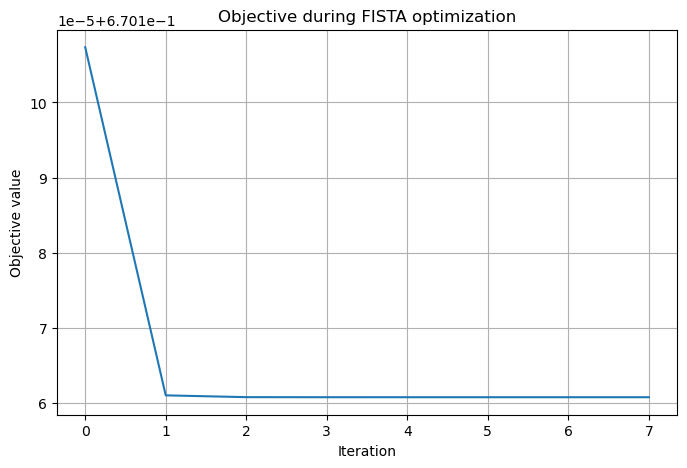

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(model.objective_history_)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Objective during FISTA optimization")
plt.grid(True)
plt.show()

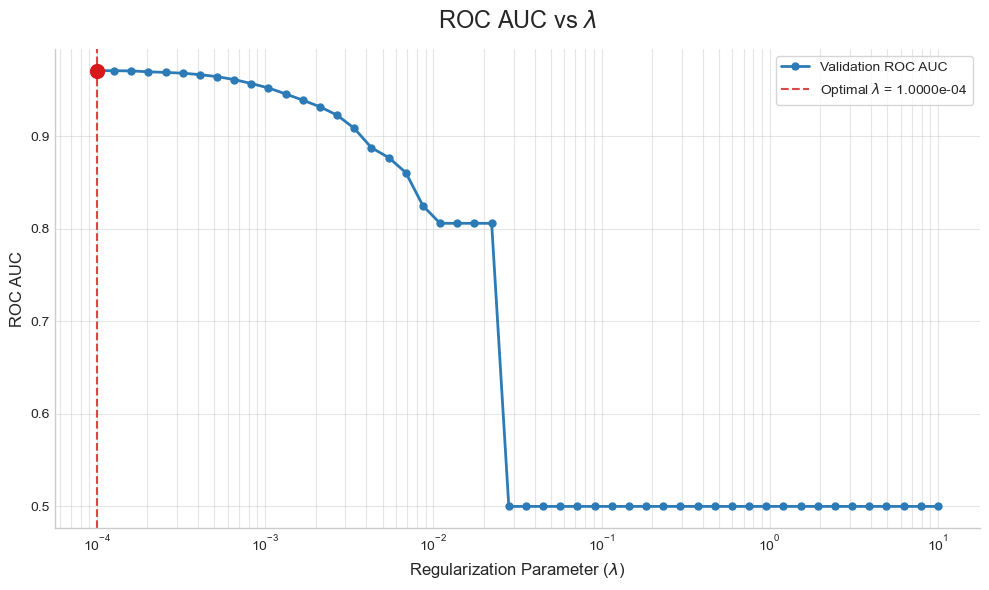

In [11]:
model.plot(X_valid=X_spam_test_scaled, y_valid=y_spam_test)

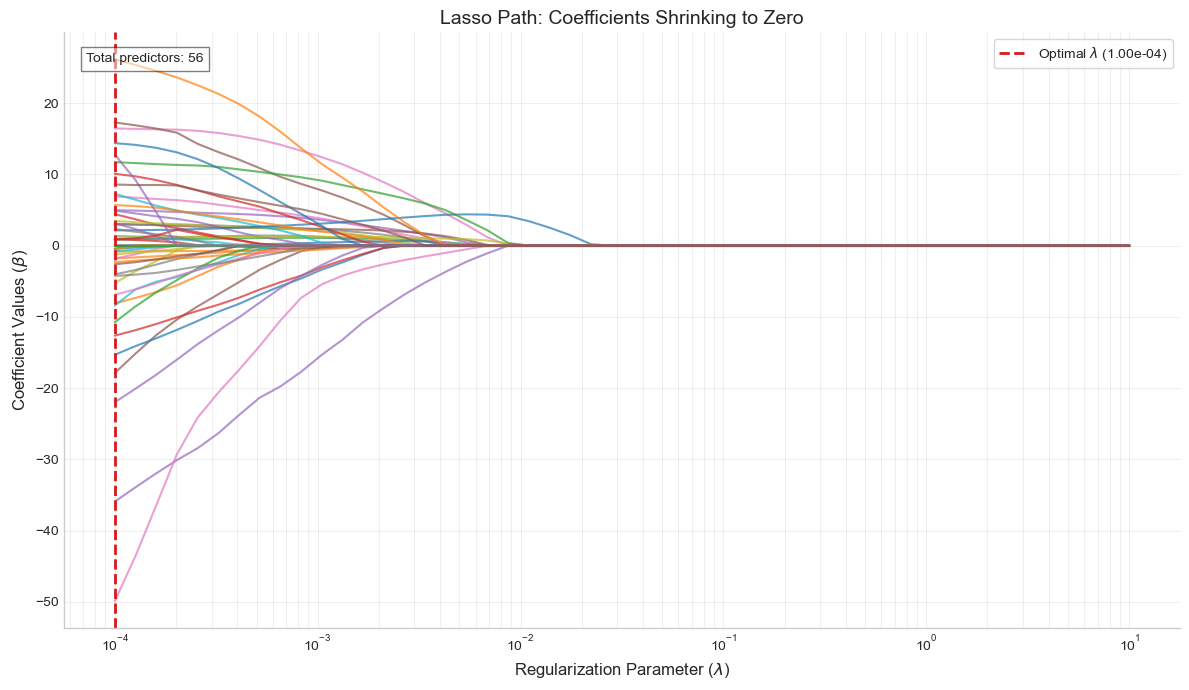

In [12]:
model.plot_coefficients()